In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definição das Funções de Ativação e suas Derivadas
# A derivada é crucial para o Backpropagation (saber a inclinação da curva)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

In [10]:
# 2. Classe da Rede Neural
class NeuralNetwork:
    def __init__(self, inputs, hidden, outputs):
        # Inicialização dos pesos com valores aleatórios pequenos
        # W1: Pesos entre Entrada e Camada Oculta
        self.weights1 = np.random.uniform(size=(inputs, hidden))
        self.bias1 = np.random.uniform(size=(1, hidden))

        # W2: Pesos entre Camada Oculta e Saída
        self.weights2 = np.random.uniform(size=(hidden, outputs))
        self.bias2 = np.random.uniform(size=(1, outputs))

        # Histórico de perdas para visualização
        self.loss_history = []

    def forward(self, X):
        """
        Propagação Direta: Input -> Hidden -> Output
        """
        # Passo 1: Input -> Hidden
        self.z1 = np.dot(X, self.weights1) + self.bias1
        self.a1 = sigmoid(self.z1) # Ativação da oculta

        # Passo 2: Hidden -> Output
        self.z2 = np.dot(self.a1, self.weights2) + self.bias2
        self.output = sigmoid(self.z2) # Previsão final
        return self.output

    def backward(self, X, y, learning_rate):
        """
        Backpropagation: O coração do aprendizado.
        Aplicação da Regra da Cadeia para atualizar pesos.
        """
        # Cálculo do Erro (Loss) - Mean Squared Error Simples
        error = y - self.output

        # == FASE 1: Gradientes da Camada de Saída ==
        # d_output = Erro * Derivada da Sigmoid na saída
        d_output = error * sigmoid_derivative(self.output)

        # Atualização W2: O quanto a camada oculta contribuiu para o erro na saída?
        # A transposta (.T) é necessária para alinhar as dimensões da matriz
        self.weights2 += np.dot(self.a1.T, d_output) * learning_rate
        self.bias2 += np.sum(d_output, axis=0, keepdims=True) * learning_rate

        # == FASE 2: Gradientes da Camada Oculta ==
        # Quanto a camada oculta errou? Propagamos o d_output para trás pelos pesos W2
        error_hidden = np.dot(d_output, self.weights2.T)
        d_hidden = error_hidden * sigmoid_derivative(self.a1)

        # Atualização W1: O quanto a entrada contribuiu para o erro na oculta?
        self.weights1 += np.dot(X.T, d_hidden) * learning_rate
        self.bias1 += np.sum(d_hidden, axis=0, keepdims=True) * learning_rate

        return np.mean(np.abs(error)) # Retorna a média do erro absoluto

    def train(self, X, y, epochs=10000, lr=0.1):
        print(f"Treinando por {epochs} épocas...")
        for i in range(epochs):
            self.forward(X)
            loss = self.backward(X, y, lr)
            self.loss_history.append(loss)

            if i % 1000 == 0:
                print(f"Época {i} | Erro: {loss:.6f}")

In [11]:
# 3. Preparação dos Dados (Problema XOR)
X = np.array([[0,0], [0,1], [1,0], [1,1]]) # Entradas
y = np.array([[0], [1], [1], [0]])         # Saídas Esperadas (XOR)

In [12]:
# 4. Execução
# Arquitetura: 2 Neurônios Entrada -> 4 Ocultos -> 1 Saída
nn = NeuralNetwork(inputs=2, hidden=4, outputs=1)

# Treinamento
nn.train(X, y, epochs=10000, lr=0.5)

Treinando por 10000 épocas...
Época 0 | Erro: 0.497620
Época 1000 | Erro: 0.154201
Época 2000 | Erro: 0.052462
Época 3000 | Erro: 0.035916
Época 4000 | Erro: 0.028594
Época 5000 | Erro: 0.024307
Época 6000 | Erro: 0.021434
Época 7000 | Erro: 0.019346
Época 8000 | Erro: 0.017745
Época 9000 | Erro: 0.016469



--- Resultados Finais ---
Entrada | Previsão | Arredondado
 [0 0] | 0.016848 | 0
 [0 1] | 0.983481 | 1
 [1 0] | 0.986642 | 1
 [1 1] | 0.014965 | 0


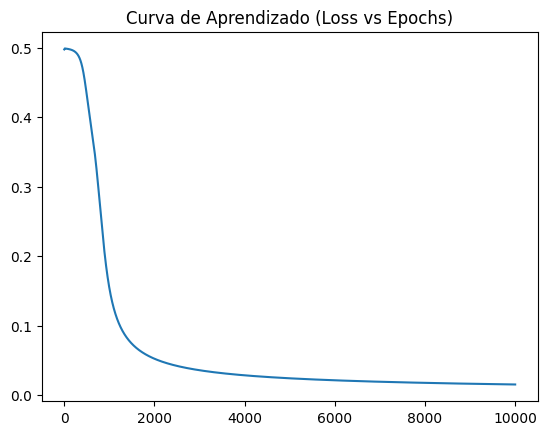

In [13]:
# 5. Teste Final (Inferência)
print("\n--- Resultados Finais ---")
print("Entrada | Previsão | Arredondado")
predictions = nn.forward(X)
for i in range(len(X)):
    print(f" {X[i]} | {predictions[i][0]:.6f} | {int(np.round(predictions[i][0]))}")

plt.plot(nn.loss_history)
plt.title("Curva de Aprendizado (Loss vs Epochs)")
plt.show()